# load libraries (set python env to be .venv/bin/activate)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#MuyGPyS imports
from MuyGPyS.gp.deformation import F2, Isotropy, l2
from MuyGPyS.gp.hyperparameter import AnalyticScale, Parameter
from MuyGPyS.gp.kernels import RBF as RBF
from MuyGPyS.gp.noise import HomoscedasticNoise
from MuyGPyS.optimize.loss import *
from muygps_wrapper_class import MuyGPSWrapper

# create artificial dataset

In [2]:
X = np.linspace(start=0, stop=10, num=1000).reshape(-1, 1)
y = np.squeeze(X * np.sin(X))

# create train/test split

In [3]:
rng = np.random.RandomState(1)
training_indices = rng.choice(np.arange(y.size), size=10, replace=False)
X_train, y_train = X[training_indices], y[training_indices]
train_count = len(X_train)

# MuyGPyS Wrapper Section
# start by setting number of nearest neighbors to use

In [4]:
nn_count = np.min([train_count-1, 30])

# Define Kernel 

In [5]:
k_kwargs = {
"kernel": RBF(
    deformation=Isotropy(
        metric=F2,
        length_scale=Parameter(1.0, (1e-2, 1e2))
    )
),
"noise": HomoscedasticNoise(1e-5),
"scale": AnalyticScale(),
}

# Initialize MuyGPyS object and train to get optimized GP and its corresponding nearest neighbors lookup

In [6]:
muygps = MuyGPSWrapper(**k_kwargs)
muygps_optimized, nbrs_lookup  = muygps.fit_regressor(X_train, y_train, nn_count=nn_count, loss_fn=lool_fn)

# Perform Inference on Test Data Using Fitted GP

In [7]:
predictions, variances = muygps_optimized.regress_any(test_features=X, train_features=X_train, train_targets=y_train, train_nbrs_lookup=nbrs_lookup)
confidence_intervals = np.sqrt(variances) * 1.96

# Create Plot showing Mean Prediction Versus Truth and Associated Confidence Intervals

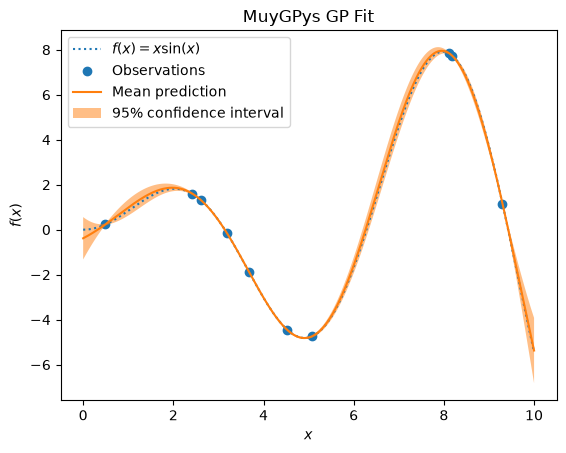

In [8]:
plt.figure()
plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.scatter(X_train, y_train, label="Observations")
plt.plot(X, predictions, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    predictions - confidence_intervals,
    predictions + confidence_intervals,
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("MuyGPys GP Fit")
plt.show()